In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
dem = rasterio.open("India_DEM.tif")

In [6]:
Karnataka = gpd.read_file("Kar_State_BND.shp")

In [7]:
print(Karnataka.crs)
print(Karnataka.geometry.geom_type.value_counts())
print(Karnataka.shape)

EPSG:32643
Polygon    15
Name: count, dtype: int64
(15, 7)


In [8]:
print("Karnataka CRS:", Karnataka.crs)
print("Raster CRS:", dem.crs)

Karnataka CRS: EPSG:32643
Raster CRS: EPSG:4326


In [9]:
Kar_projected = Karnataka.to_crs(dem.crs)

In [10]:
from rasterio.mask import mask

In [11]:
geometries = Kar_projected.geometry.values

In [12]:
clipped, clipped_transform = mask(
    dem,
    geometries,
    crop=True
)

In [13]:
original = dem.read(1)

print("Original shape:", original.shape)
print("Clipped shape:", clipped[0].shape)

Original shape: (3641, 3515)
Clipped shape: (827, 541)


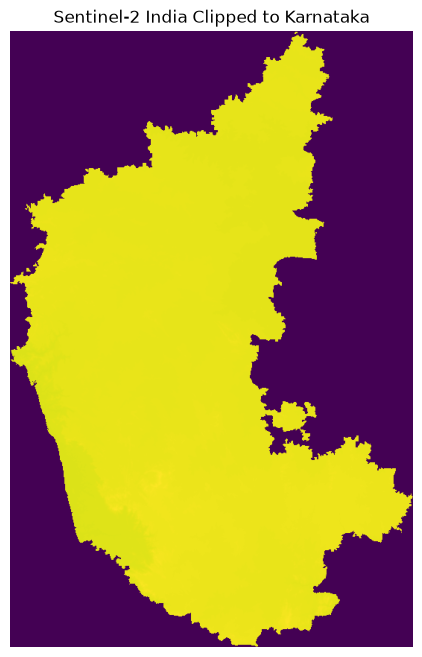

In [14]:
plt.figure(figsize=(8, 8))

plt.imshow(clipped[0])

plt.axis("off")

plt.title("Sentinel-2 India Clipped to Karnataka")

plt.savefig("Kar_State.tif")

plt.show()

In [19]:
#Kar_State = clipped.read(1)

In [5]:
clipped = rasterio.open("KA.tif")

# Read DEM and keep NoData as a mask
elevation_masked = clipped.read(1, masked=True)

# Create a floating-point version for calculations
elevation = elevation_masked.astype("float32").filled(np.nan)

print("CRS:", clipped.crs)
print("Resolution:", clipped.res)
print("Width:", clipped.width)
print("Height:", clipped.height)
print("Minimum Elevation:", elevation_masked.min())
print("Maximum Elevation:", elevation_masked.max())

CRS: EPSG:4326
Resolution: (0.008333333332096475, 0.008333333333333335)
Width: 539
Height: 825
Minimum Elevation: 0
Maximum Elevation: 1808


In [7]:
longitude = np.linspace(
    clipped.bounds.left,
    clipped.bounds.right,
    clipped.width
)

latitude = np.linspace(
    clipped.bounds.top,
    clipped.bounds.bottom,
    clipped.height
)

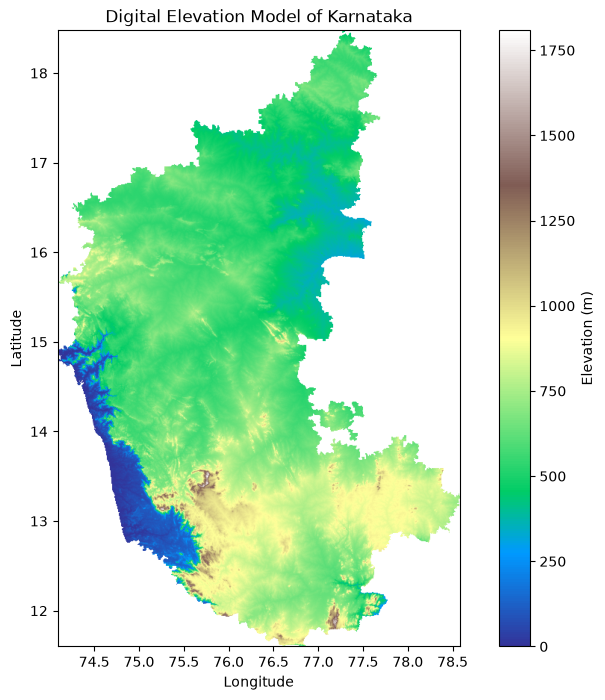

In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(
    elevation_masked,
    cmap="terrain",
    extent=[
        clipped.bounds.left,
        clipped.bounds.right,
        clipped.bounds.bottom,
        clipped.bounds.top
    ]
)

plt.colorbar(label="Elevation (m)")

plt.title("Digital Elevation Model of Karnataka")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("KA-DEM.png", dpi=600, bbox_inches="tight")
plt.show()

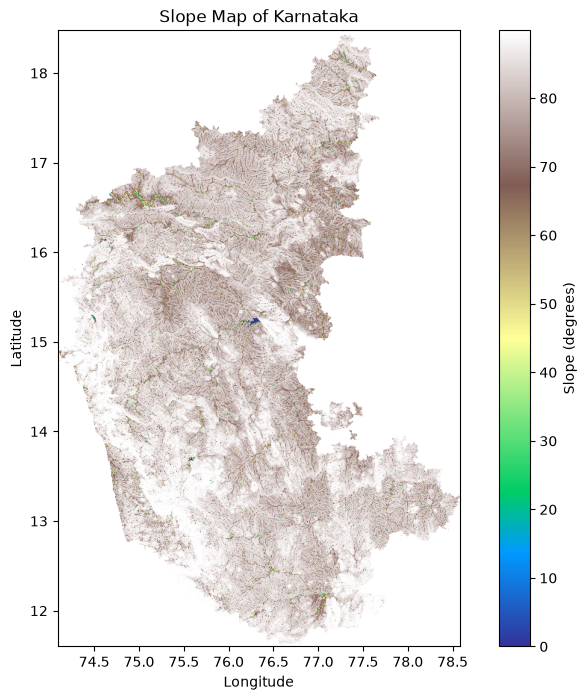

In [10]:
dy, dx = np.gradient(elevation)

slope = np.degrees(
    np.arctan(
        np.sqrt(dx**2 + dy**2)
    )
)

plt.figure(figsize=(10, 8))

plt.imshow(
    slope,
    cmap="terrain",
    extent=[
        clipped.bounds.left,
        clipped.bounds.right,
        clipped.bounds.bottom,
        clipped.bounds.top
    ]
)

plt.colorbar(label="Slope (degrees)")

plt.title("Slope Map of Karnataka")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("KA-Slope.png", dpi=600, bbox_inches="tight")
plt.show()

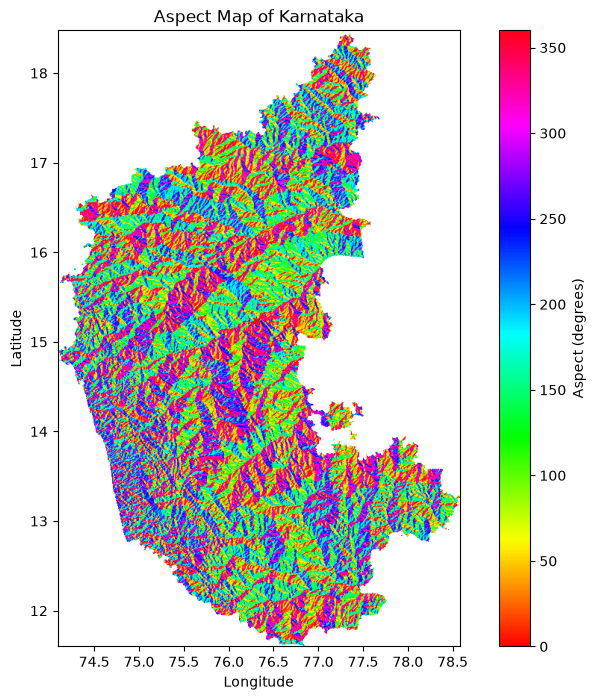

In [11]:
aspect = np.degrees(
    np.arctan2(-dx, dy)
)

aspect = (aspect + 360) % 360

plt.figure(figsize=(10, 8))

plt.imshow(
    aspect,
    cmap="hsv",
    vmin=0,
    vmax=360,
    extent=[
        clipped.bounds.left,
        clipped.bounds.right,
        clipped.bounds.bottom,
        clipped.bounds.top
    ]
)

plt.colorbar(label="Aspect (degrees)")

plt.title("Aspect Map of Karnataka")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("KA-Aspect.png", dpi=600, bbox_inches="tight")
plt.show()

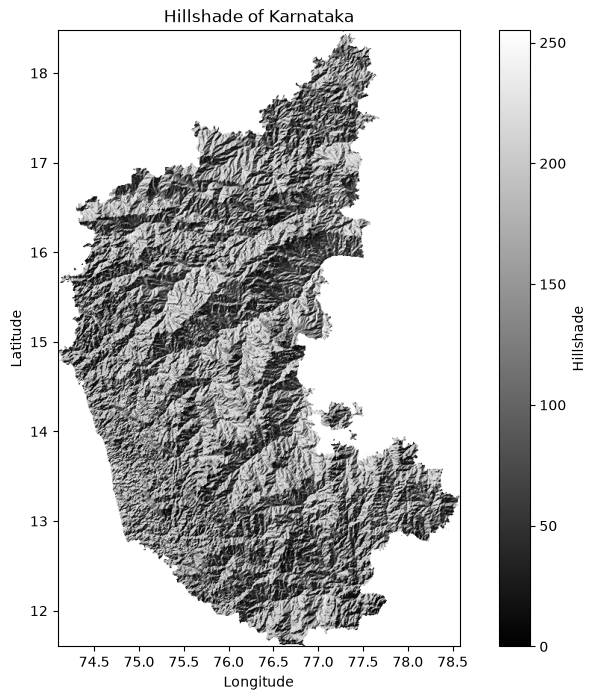

In [12]:
azimuth = 315
altitude = 45

slope_rad = np.radians(slope)
aspect_rad = np.radians(aspect)

azimuth_rad = np.radians(azimuth)
altitude_rad = np.radians(altitude)



hillshade = (
    np.sin(altitude_rad) * np.cos(slope_rad)
    +
    np.cos(altitude_rad)
    * np.sin(slope_rad)
    * np.cos(azimuth_rad - aspect_rad)
)

hillshade = (
    (hillshade - np.nanmin(hillshade))
    /
    (np.nanmax(hillshade) - np.nanmin(hillshade))
    * 255
)

plt.figure(figsize=(10, 8))

plt.imshow(
    hillshade,
    cmap="gray",
    extent=[
        clipped.bounds.left,
        clipped.bounds.right,
        clipped.bounds.bottom,
        clipped.bounds.top
    ]
)

plt.colorbar(label="Hillshade")

plt.title("Hillshade of Karnataka")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("KA-Hillshade.png", dpi=600, bbox_inches="tight")
plt.show()

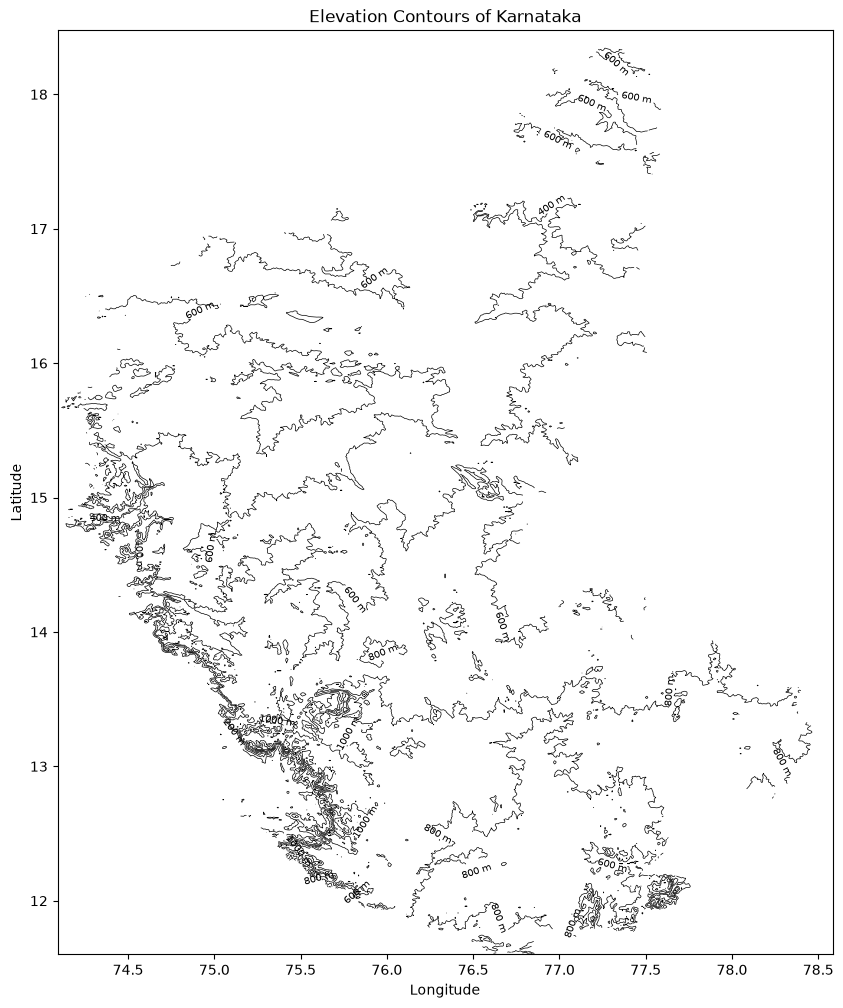

In [16]:
X, Y = np.meshgrid(
    longitude,
    latitude
)

levels = np.arange(0, 8500, 200)

plt.figure(figsize=(10, 12))

contours = plt.contour(
    X,
    Y,
    elevation_masked,
    levels=levels,
    colors="black",
    linewidths=0.5
)

plt.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m"
)

plt.title("Elevation Contours of Karnataka")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("KA-Contours.png", dpi=600, bbox_inches="tight")
plt.show()